# Experiment: ASH IMC Candidate Comparison

Compare the official IMC backtests for candidates `A` through `D`, reconcile them with the latest local proxy run, and use the measured step changes to frame a credible path toward `3500.0` official PnL.

Success criteria:
- the official scoreboard exactly matches the saved IMC exports
- the local proxy explains useful mechanism without overriding the official ranking
- the notebook ends with a roadmap that matches the implemented local `E/F/G` next-round family


In [1]:
# Setup: imports and notebook defaults
from __future__ import annotations

import ast
import json
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10


## Plan

- Use the official IMC exports as the ranking source of truth for candidates `A`, `B`, `C`, and `D`.
- Use the latest local run `outputs/ash_coated_osmium/20260416_102921` only to explain why the ranking changes, not to override it.
- Quantify the exact gap from candidate `D`'s official result to the fixed `3500.0` target.
- End with a roadmap for the implemented local `E/F/G` next-round family while keeping the official `A-D` comparison fixed.


In [2]:
# Config: paths, constants, and reusable loaders
PROJECT_ROOT = Path.cwd()
TARGET_PRODUCT = 'ASH_COATED_OSMIUM'
TARGET_OFFICIAL_PNL = 3500.0
LOCAL_RUN_LABEL = '20260416_102921'
LOCAL_RUN_DIR = PROJECT_ROOT / 'outputs' / 'ash_coated_osmium' / LOCAL_RUN_LABEL
OFFICIAL_RESULT_DIRS = {
    candidate: PROJECT_ROOT / 'imc backtest results' / f'candidate {candidate}'
    for candidate in ['A', 'B', 'C', 'D']
}
CANDIDATE_FILES = {
    candidate: PROJECT_ROOT / 'submissions' / f'ash_candidate_{candidate}.py'
    for candidate in ['A', 'B', 'C', 'D']
}
PROFILE_ORDER = ['strict', 'loose']
CANDIDATE_ORDER = list(CANDIDATE_FILES)

assert LOCAL_RUN_DIR.exists(), f'Missing local run directory: {LOCAL_RUN_DIR}'
for path in OFFICIAL_RESULT_DIRS.values():
    assert path.exists(), f'Missing official result directory: {path}'
for path in CANDIDATE_FILES.values():
    assert path.exists(), f'Missing candidate file: {path}'


def with_candidate_order(frame: pd.DataFrame, column: str = 'candidate') -> pd.DataFrame:
    out = frame.copy()
    out[column] = pd.Categorical(out[column], categories=CANDIDATE_ORDER, ordered=True)
    return out.sort_values(column).reset_index(drop=True)


def load_regime_config(py_path: Path) -> dict[str, object]:
    module = ast.parse(py_path.read_text(), filename=str(py_path))
    for node in module.body:
        if isinstance(node, ast.ClassDef) and node.name == 'RegimeMMConfig':
            config: dict[str, object] = {}
            for stmt in node.body:
                if isinstance(stmt, ast.AnnAssign) and isinstance(stmt.target, ast.Name) and stmt.value is not None:
                    try:
                        config[stmt.target.id] = ast.literal_eval(stmt.value)
                    except Exception:
                        continue
            return config
    raise AssertionError(f'Could not find RegimeMMConfig in {py_path}')


def read_semicolon_csv(raw_text: str | None, empty_columns: list[str] | None = None) -> pd.DataFrame:
    if raw_text:
        return pd.read_csv(StringIO(raw_text), sep=';')
    return pd.DataFrame(columns=empty_columns or [])


def load_official_candidate(result_dir: Path) -> dict[str, object]:
    json_path = next(result_dir.glob('*.json'))
    log_path = next(result_dir.glob('*.log'))

    result_json = json.loads(json_path.read_text())
    result_log = json.loads(log_path.read_text())

    positions = pd.DataFrame(result_json.get('positions', []))
    if not positions.empty and 'quantity' in positions.columns:
        positions['quantity'] = pd.to_numeric(positions['quantity'], errors='coerce')

    activities = read_semicolon_csv(result_log.get('activitiesLog'))
    if not activities.empty:
        numeric_cols = [col for col in activities.columns if col != 'product']
        activities[numeric_cols] = activities[numeric_cols].apply(pd.to_numeric, errors='coerce')
        activities = activities.sort_values(['day', 'product', 'timestamp']).reset_index(drop=True)

    ash_activities = activities.loc[activities['product'] == TARGET_PRODUCT].copy()
    ash_activities = ash_activities.sort_values('timestamp').reset_index(drop=True)

    trade_history = pd.DataFrame(result_log.get('tradeHistory', []))
    if not trade_history.empty:
        for col in ['timestamp', 'price', 'quantity']:
            if col in trade_history.columns:
                trade_history[col] = pd.to_numeric(trade_history[col], errors='coerce')
    if not trade_history.empty and 'symbol' in trade_history.columns:
        ash_trades = trade_history.loc[trade_history['symbol'] == TARGET_PRODUCT].copy()
    else:
        ash_trades = pd.DataFrame()

    if not ash_trades.empty:
        ash_trades['submission_side'] = np.select(
            [ash_trades['buyer'] == 'SUBMISSION', ash_trades['seller'] == 'SUBMISSION'],
            ['buy', 'sell'],
            default='other',
        )
    else:
        ash_trades = pd.DataFrame(
            columns=['timestamp', 'buyer', 'seller', 'symbol', 'price', 'quantity', 'submission_side']
        )

    return {
        'json_path': json_path,
        'log_path': log_path,
        'result_json': result_json,
        'result_log': result_log,
        'positions': positions,
        'activities': activities,
        'ash_activities': ash_activities,
        'trade_history': trade_history,
        'ash_trades': ash_trades,
    }


def load_local_candidate(candidate: str) -> dict[str, dict[str, pd.DataFrame]]:
    payload: dict[str, dict[str, pd.DataFrame]] = {}
    for profile in PROFILE_ORDER:
        base = LOCAL_RUN_DIR / candidate / profile
        summary = pd.read_csv(base / 'summary.csv')
        daily = pd.read_csv(base / 'daily_pnl.csv')
        fills = pd.read_csv(base / 'fills.csv')

        summary['candidate'] = candidate
        summary['profile'] = profile
        daily['candidate'] = candidate
        daily['profile'] = profile
        fills['candidate'] = candidate
        fills['profile'] = profile

        payload[profile] = {
            'summary': summary,
            'daily': daily,
            'fills': fills,
        }
    return payload


config_view = pd.DataFrame(
    {
        'setting': ['TARGET_PRODUCT', 'TARGET_OFFICIAL_PNL', 'LOCAL_RUN_LABEL', 'PROJECT_ROOT'],
        'value': [TARGET_PRODUCT, TARGET_OFFICIAL_PNL, LOCAL_RUN_LABEL, str(PROJECT_ROOT)],
    }
)
display(config_view)


,setting,value
0,TARGET_PRODUCT,ASH_COATED_OSMIUM
1,TARGET_OFFICIAL_PNL,3500.0
2,LOCAL_RUN_LABEL,20260416_102921
3,PROJECT_ROOT,/Users/shanilshah/Desktop/coding/imc prosperit...


## Load official IMC results and local proxy diagnostics

The official IMC exports are the ranking source of truth. The local run adds richer diagnostics such as worst-day behavior, fill mix, and adverse-selection proxies.


In [3]:
# Load candidate configs, official IMC results, and local proxy outputs
candidate_configs = {candidate: load_regime_config(path) for candidate, path in CANDIDATE_FILES.items()}
official_payloads = {candidate: load_official_candidate(path) for candidate, path in OFFICIAL_RESULT_DIRS.items()}
local_payloads = {candidate: load_local_candidate(candidate) for candidate in CANDIDATE_ORDER}

official_rows = []
official_pnl_path_frames = []
local_summary_frames = []
local_daily_frames = []
local_fill_frames = []

for candidate in CANDIDATE_ORDER:
    official = official_payloads[candidate]
    positions = official['positions']
    submission_trades = official['ash_trades'].loc[official['ash_trades']['submission_side'] != 'other'].copy()

    final_inventory = np.nan
    cash_balance = np.nan
    if not positions.empty:
        target_pos = positions.loc[positions['symbol'] == TARGET_PRODUCT, 'quantity']
        cash_pos = positions.loc[positions['symbol'] == 'XIRECS', 'quantity']
        if not target_pos.empty:
            final_inventory = float(target_pos.iloc[0])
        if not cash_pos.empty:
            cash_balance = float(cash_pos.iloc[0])

    official_rows.append(
        {
            'candidate': candidate,
            'status': official['result_json']['status'],
            'official_pnl': float(official['result_json']['profit']),
            'submission_trade_count': int(len(submission_trades)),
            'submission_buy_trades': int((submission_trades['submission_side'] == 'buy').sum()),
            'submission_sell_trades': int((submission_trades['submission_side'] == 'sell').sum()),
            'avg_trade_qty': float(submission_trades['quantity'].mean()) if not submission_trades.empty else np.nan,
            'final_inventory': final_inventory,
            'cash_balance': cash_balance,
        }
    )

    pnl_path = official['ash_activities'][['timestamp', 'profit_and_loss']].copy()
    pnl_path['candidate'] = candidate
    official_pnl_path_frames.append(pnl_path)

    for profile in PROFILE_ORDER:
        local_summary_frames.append(local_payloads[candidate][profile]['summary'])
        local_daily_frames.append(local_payloads[candidate][profile]['daily'])
        local_fill_frames.append(local_payloads[candidate][profile]['fills'])

official_by_candidate = with_candidate_order(pd.DataFrame(official_rows), 'candidate')
official_by_candidate['uplift_vs_A'] = official_by_candidate['official_pnl'] - official_by_candidate.loc[0, 'official_pnl']
official_by_candidate['uplift_vs_prior'] = official_by_candidate['official_pnl'].diff().fillna(0.0)

official_ranking = official_by_candidate.sort_values('official_pnl', ascending=False).reset_index(drop=True)
official_ranking['official_rank'] = official_ranking.index + 1
official_scoreboard = with_candidate_order(
    official_by_candidate.merge(official_ranking[['candidate', 'official_rank']], on='candidate'),
    'candidate',
)

official_pnl_paths = pd.concat(official_pnl_path_frames, ignore_index=True)
official_pnl_paths['candidate'] = pd.Categorical(official_pnl_paths['candidate'], categories=CANDIDATE_ORDER, ordered=True)
official_pnl_paths = official_pnl_paths.sort_values(['candidate', 'timestamp']).reset_index(drop=True)

local_summary = pd.concat(local_summary_frames, ignore_index=True)
local_summary = with_candidate_order(local_summary, 'candidate')
local_summary['profile'] = pd.Categorical(local_summary['profile'], categories=PROFILE_ORDER, ordered=True)
local_summary = local_summary.sort_values(['candidate', 'profile']).reset_index(drop=True)

local_daily = pd.concat(local_daily_frames, ignore_index=True)
local_daily = with_candidate_order(local_daily, 'candidate')
local_daily['profile'] = pd.Categorical(local_daily['profile'], categories=PROFILE_ORDER, ordered=True)
local_daily = local_daily.sort_values(['candidate', 'profile', 'day']).reset_index(drop=True)

local_fills = pd.concat(local_fill_frames, ignore_index=True)
local_fills = with_candidate_order(local_fills, 'candidate')
local_fills['profile'] = pd.Categorical(local_fills['profile'], categories=PROFILE_ORDER, ordered=True)
local_fills = local_fills.sort_values(['candidate', 'profile', 'timestamp']).reset_index(drop=True)

strict_local_ranking = (
    local_summary.loc[local_summary['profile'] == 'strict']
    .sort_values('net_pnl', ascending=False)
    .reset_index(drop=True)
)
strict_local_ranking['local_strict_rank'] = strict_local_ranking.index + 1
strict_local_by_candidate = with_candidate_order(strict_local_ranking, 'candidate')

strict_fills = local_fills.loc[local_fills['profile'] == 'strict'].copy()
strict_fills['passive_qty'] = np.where(strict_fills['liquidity'] == 'passive', strict_fills['qty'], 0.0)
strict_fills['buy_qty'] = np.where(strict_fills['side'] == 'buy', strict_fills['qty'], 0.0)
strict_fills['sell_qty'] = np.where(strict_fills['side'] == 'sell', strict_fills['qty'], 0.0)
strict_fill_qty_summary = (
    strict_fills.groupby('candidate', observed=False)
    .agg(
        total_fill_qty=('qty', 'sum'),
        mean_fill_qty=('qty', 'mean'),
        passive_fill_qty=('passive_qty', 'sum'),
        buy_qty=('buy_qty', 'sum'),
        sell_qty=('sell_qty', 'sum'),
    )
    .reset_index()
)
strict_fill_qty_summary['passive_fill_qty_share'] = (
    strict_fill_qty_summary['passive_fill_qty'] / strict_fill_qty_summary['total_fill_qty']
)
strict_fill_qty_summary = with_candidate_order(strict_fill_qty_summary, 'candidate')

display(official_scoreboard[['candidate', 'official_pnl', 'submission_trade_count', 'avg_trade_qty', 'final_inventory']].round(5))
display(
    local_summary[
        [
            'candidate',
            'profile',
            'net_pnl',
            'worst_day_pnl',
            'fill_count',
            'passive_share',
            'avg_signed_mid_move_5',
            'max_abs_inventory',
            'near_limit_share',
        ]
    ].round(6)
)


,candidate,official_pnl,submission_trade_count,avg_trade_qty,final_inventory
0,A,836.56250,54,4.29630,-2.0
1,B,949.00000,55,4.25455,0.0
2,C,1125.00000,53,4.22642,0.0
3,D,1386.84375,52,5.75000,-3.0


,candidate,profile,net_pnl,worst_day_pnl,fill_count,passive_share,avg_signed_mid_move_5,max_abs_inventory,near_limit_share
0,A,strict,3496.000,1081.000,273,0.989011,-0.697415,14.50,0.000000
1,A,loose,9809.375,3015.500,1317,0.997722,-2.835015,16.75,0.015033
2,B,strict,3478.500,1074.500,277,0.989170,-0.650801,15.00,0.023333
3,B,loose,9740.500,2982.125,1343,0.997766,-2.868316,16.75,0.053767
4,C,strict,3397.000,999.500,273,0.989011,-0.723566,15.00,0.010900
5,C,loose,9695.625,3068.500,1336,0.997754,-2.854053,16.75,0.041500
6,D,strict,3579.000,958.000,277,0.989170,-0.614761,21.00,0.000000
7,D,loose,10255.375,3208.500,1356,0.997788,-2.964749,27.25,0.000000


## Official IMC scoreboard

This table and chart are the ranking source of truth. The `uplift_vs_prior` column follows the candidate ladder `A -> B -> C -> D`, while the `official_rank` column reflects the final IMC ordering.


,candidate,official_rank,official_pnl,uplift_vs_A,uplift_vs_prior,submission_trade_count,avg_trade_qty,final_inventory,cash_balance
0,A,4,836.56250,0.00000,0.00000,54,4.29630,-2.0,20842.0
1,B,3,949.00000,112.43750,112.43750,55,4.25455,0.0,949.0
2,C,2,1125.00000,288.43750,176.00000,53,4.22642,0.0,1125.0
3,D,1,1386.84375,550.28125,261.84375,52,5.75000,-3.0,31395.0


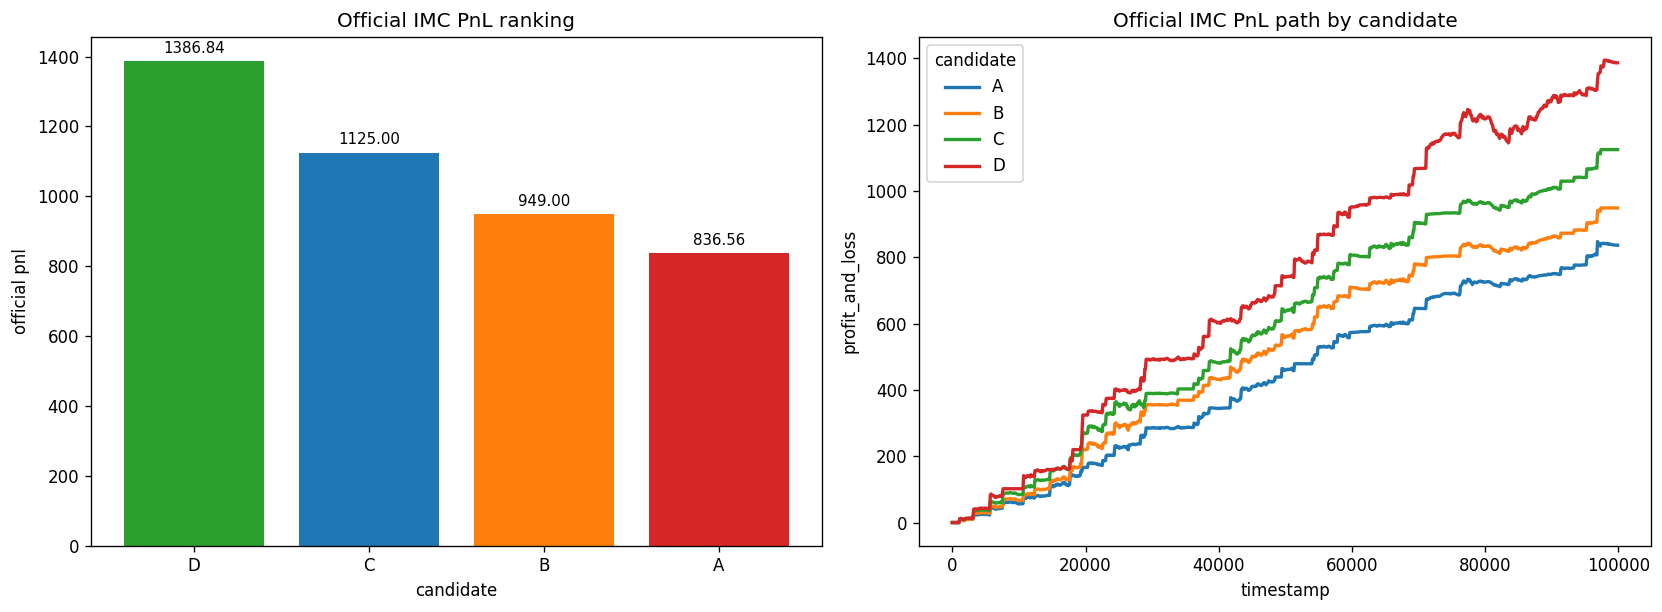

In [4]:
official_scoreboard_view = official_scoreboard[
    [
        'candidate',
        'official_rank',
        'official_pnl',
        'uplift_vs_A',
        'uplift_vs_prior',
        'submission_trade_count',
        'avg_trade_qty',
        'final_inventory',
        'cash_balance',
    ]
].round(5)
display(official_scoreboard_view)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ranked = official_ranking.copy()
axes[0].bar(ranked['candidate'].astype(str), ranked['official_pnl'], color=['tab:green', 'tab:blue', 'tab:orange', 'tab:red'])
axes[0].set_title('Official IMC PnL ranking')
axes[0].set_xlabel('candidate')
axes[0].set_ylabel('official pnl')
for row in ranked.itertuples(index=False):
    axes[0].text(row.candidate, row.official_pnl + 15.0, f'{row.official_pnl:.2f}', ha='center', va='bottom', fontsize=9)

for candidate, frame in official_pnl_paths.groupby('candidate', observed=False):
    axes[1].plot(frame['timestamp'], frame['profit_and_loss'], linewidth=2, label=str(candidate))
axes[1].set_title('Official IMC PnL path by candidate')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('profit_and_loss')
axes[1].legend(title='candidate', loc='best')

plt.tight_layout()
plt.show()


## Local strict and loose scoreboard

The local run is not the ranking source of truth, but it exposes richer diagnostics: worst day, fill count, passive share, adverse-selection proxy, and inventory pressure.


,candidate,profile,net_pnl,worst_day_pnl,fill_count,passive_share,avg_signed_mid_move_5,max_abs_inventory,near_limit_share
0,A,strict,3496.000,1081.000,273,0.989011,-0.697415,14.50,0.000000
1,A,loose,9809.375,3015.500,1317,0.997722,-2.835015,16.75,0.015033
2,B,strict,3478.500,1074.500,277,0.989170,-0.650801,15.00,0.023333
3,B,loose,9740.500,2982.125,1343,0.997766,-2.868316,16.75,0.053767
4,C,strict,3397.000,999.500,273,0.989011,-0.723566,15.00,0.010900
5,C,loose,9695.625,3068.500,1336,0.997754,-2.854053,16.75,0.041500
6,D,strict,3579.000,958.000,277,0.989170,-0.614761,21.00,0.000000
7,D,loose,10255.375,3208.500,1356,0.997788,-2.964749,27.25,0.000000


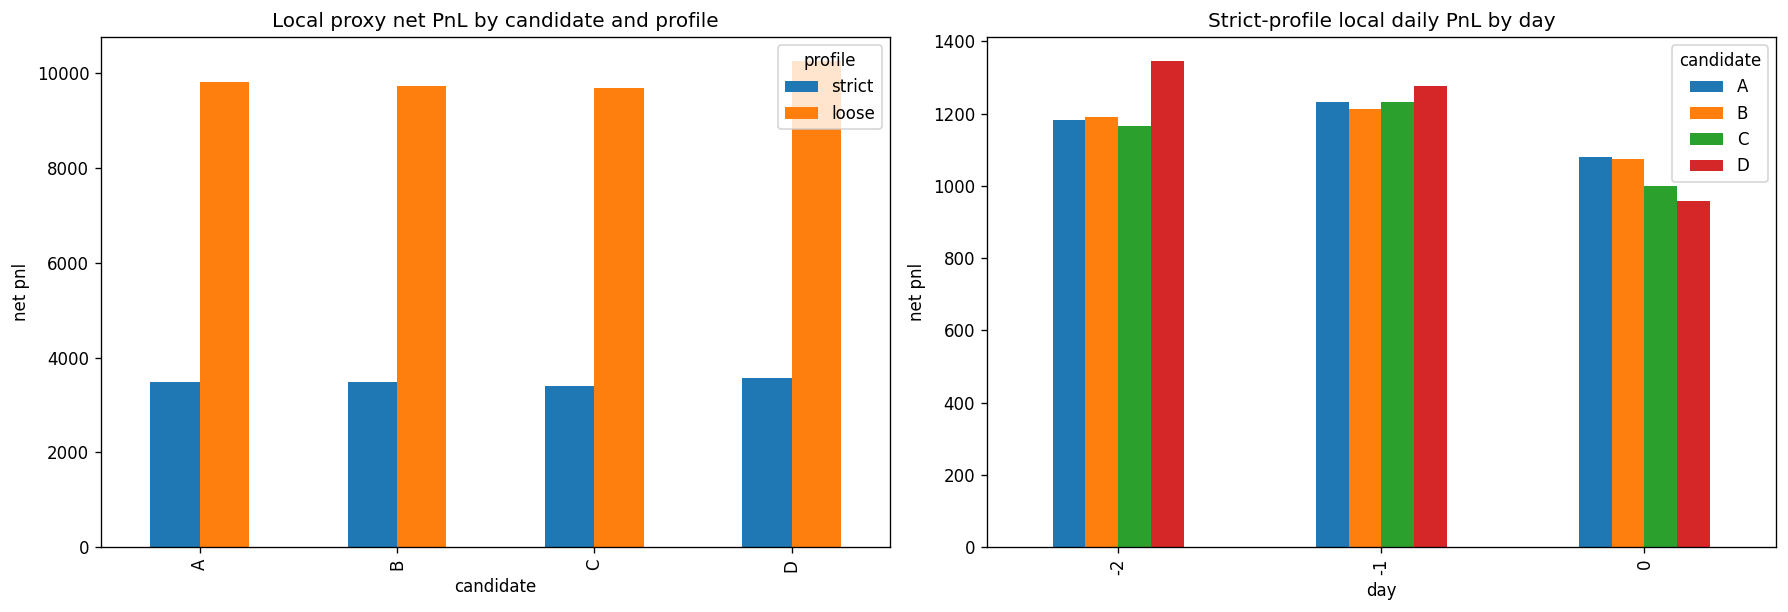

,candidate,total_fill_qty,mean_fill_qty,passive_fill_qty_share,buy_qty,sell_qty
0,A,586.0,2.146520,0.957338,293.0,293.0
1,B,586.0,2.115523,0.959044,293.0,293.0
2,C,584.0,2.139194,0.955479,292.0,292.0
3,D,623.0,2.249097,0.940610,311.5,311.5


In [5]:
local_scoreboard_view = local_summary[
    [
        'candidate',
        'profile',
        'net_pnl',
        'worst_day_pnl',
        'fill_count',
        'passive_share',
        'avg_signed_mid_move_5',
        'max_abs_inventory',
        'near_limit_share',
    ]
].round(6)
display(local_scoreboard_view)

net_pnl_pivot = (
    local_summary.pivot(index='candidate', columns='profile', values='net_pnl')
    .reindex(CANDIDATE_ORDER)
    .reindex(columns=PROFILE_ORDER)
)
strict_daily_pivot = (
    local_daily.loc[local_daily['profile'] == 'strict']
    .pivot(index='day', columns='candidate', values='net_pnl')
    .sort_index()
    .reindex(columns=CANDIDATE_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
net_pnl_pivot.plot(kind='bar', ax=axes[0], color=['tab:blue', 'tab:orange'])
axes[0].set_title('Local proxy net PnL by candidate and profile')
axes[0].set_xlabel('candidate')
axes[0].set_ylabel('net pnl')
axes[0].legend(title='profile', loc='best')

strict_daily_pivot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Strict-profile local daily PnL by day')
axes[1].set_xlabel('day')
axes[1].set_ylabel('net pnl')
axes[1].legend(title='candidate', loc='best')

plt.tight_layout()
plt.show()

display(
    strict_fill_qty_summary[
        ['candidate', 'total_fill_qty', 'mean_fill_qty', 'passive_fill_qty_share', 'buy_qty', 'sell_qty']
    ].round(6)
)


## Calibration: official vs local rank drift

This section makes the ranking disagreement explicit instead of hiding it. The local proxy is useful only if we can see where it matches the official site and where it drifts.


,candidate,official_rank,official_pnl,local_strict_rank,local_strict_pnl,avg_signed_mid_move_5,max_abs_inventory,near_limit_share,official_to_local_ratio,rank_delta_local_minus_official
0,A,4,836.56250,2,3496.0,-0.697415,14.5,0.000000,0.239291,-2
1,B,3,949.00000,3,3478.5,-0.650801,15.0,0.023333,0.272819,0
2,C,2,1125.00000,4,3397.0,-0.723566,15.0,0.010900,0.331175,2
3,D,1,1386.84375,1,3579.0,-0.614761,21.0,0.000000,0.387495,0


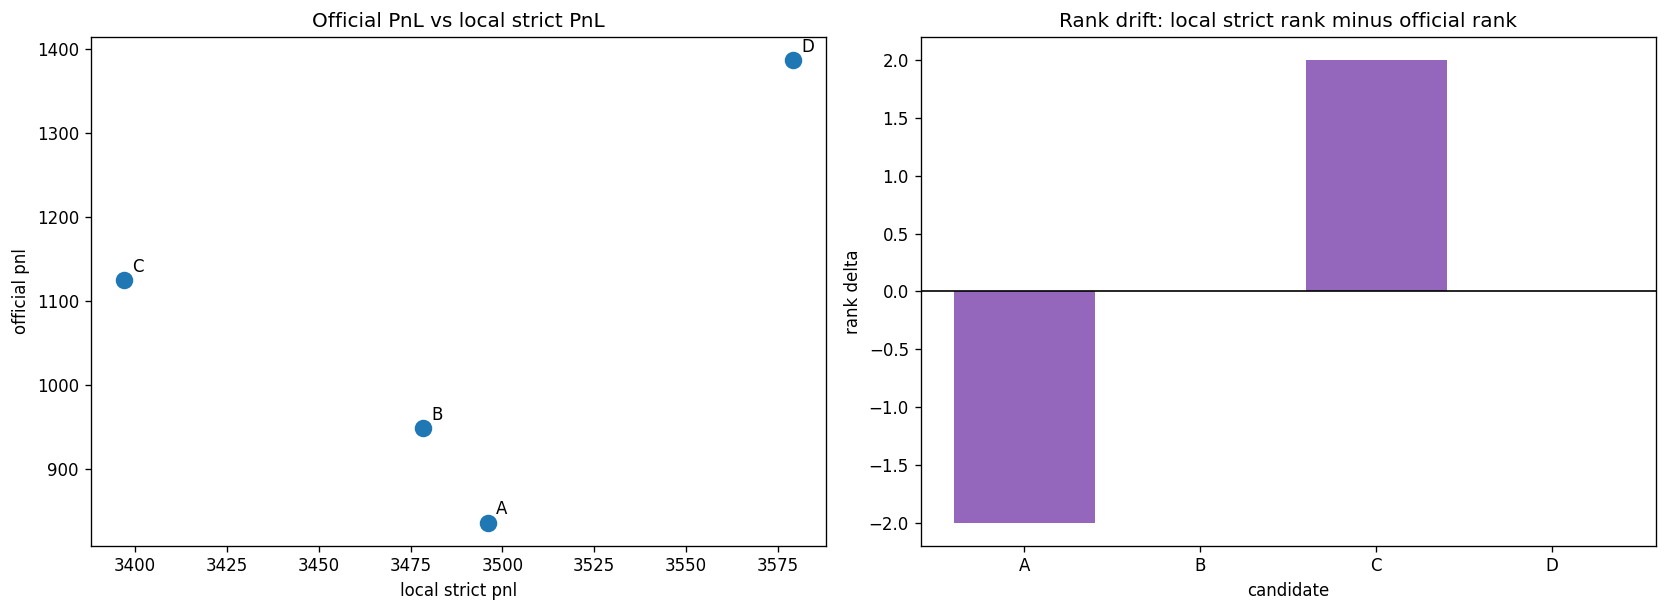

**Calibration note**

- The local proxy still identifies `D` as the best candidate, which is the main directional win.
- It over-ranks `A` and under-ranks `C`, so the official IMC exports must remain the ranking source of truth.
- The `official_to_local_ratio` rises from `A` to `D`, which means the local proxy understates the official payoff of later ladder changes, especially the jump into `D`.

In [6]:
calibration = official_scoreboard[
    ['candidate', 'official_rank', 'official_pnl']
].merge(
    strict_local_by_candidate[
        ['candidate', 'local_strict_rank', 'net_pnl', 'avg_signed_mid_move_5', 'max_abs_inventory', 'near_limit_share']
    ].rename(columns={'net_pnl': 'local_strict_pnl'}),
    on='candidate',
    how='inner',
)
calibration['official_to_local_ratio'] = calibration['official_pnl'] / calibration['local_strict_pnl']
calibration['rank_delta_local_minus_official'] = calibration['local_strict_rank'] - calibration['official_rank']
calibration = with_candidate_order(calibration, 'candidate')
display(calibration.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].scatter(calibration['local_strict_pnl'], calibration['official_pnl'], s=90, color='tab:blue')
for row in calibration.itertuples(index=False):
    axes[0].annotate(row.candidate, (row.local_strict_pnl, row.official_pnl), textcoords='offset points', xytext=(5, 5))
axes[0].set_title('Official PnL vs local strict PnL')
axes[0].set_xlabel('local strict pnl')
axes[0].set_ylabel('official pnl')

axes[1].bar(calibration['candidate'].astype(str), calibration['rank_delta_local_minus_official'], color='tab:purple')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Rank drift: local strict rank minus official rank')
axes[1].set_xlabel('candidate')
axes[1].set_ylabel('rank delta')

plt.tight_layout()
plt.show()

rank_drift_note = chr(10).join(
    [
        '**Calibration note**',
        '',
        '- The local proxy still identifies `D` as the best candidate, which is the main directional win.',
        '- It over-ranks `A` and under-ranks `C`, so the official IMC exports must remain the ranking source of truth.',
        '- The `official_to_local_ratio` rises from `A` to `D`, which means the local proxy understates the official payoff of later ladder changes, especially the jump into `D`.',
    ]
)
display(Markdown(rank_drift_note))


## Parameter ladder and step deltas

The table below isolates exactly what changed between each candidate and connects those changes to both the official IMC result and the local strict proxy.


,candidate,anchor_lookback,base_half_spread,inventory_skew,imbalance_skew,dislocation_threshold,defensive_widening_multiplier,max_quote_size,inventory_soft_limit,inventory_hard_limit,enable_dislocation_takers,dislocation_one_sided_only
0,A,30,4.0,0.4,1.0,5.0,2.0,5.0,12.0,20.0,False,True
1,B,40,4.0,0.2,1.0,5.0,2.0,5.0,12.0,20.0,False,True
2,C,30,5.0,0.2,1.0,5.0,1.5,5.0,12.0,20.0,False,True
3,D,30,5.0,0.2,1.0,5.0,1.5,10.0,24.0,40.0,False,True


,step,changed_fields,official_delta,local_strict_delta
0,A -> B,anchor_lookback 30 -> 40; inventory_skew 0.4 -...,112.43750,-17.5
1,B -> C,anchor_lookback 40 -> 30; base_half_spread 4.0...,176.00000,-81.5
2,C -> D,max_quote_size 5.0 -> 10.0; inventory_soft_lim...,261.84375,182.0


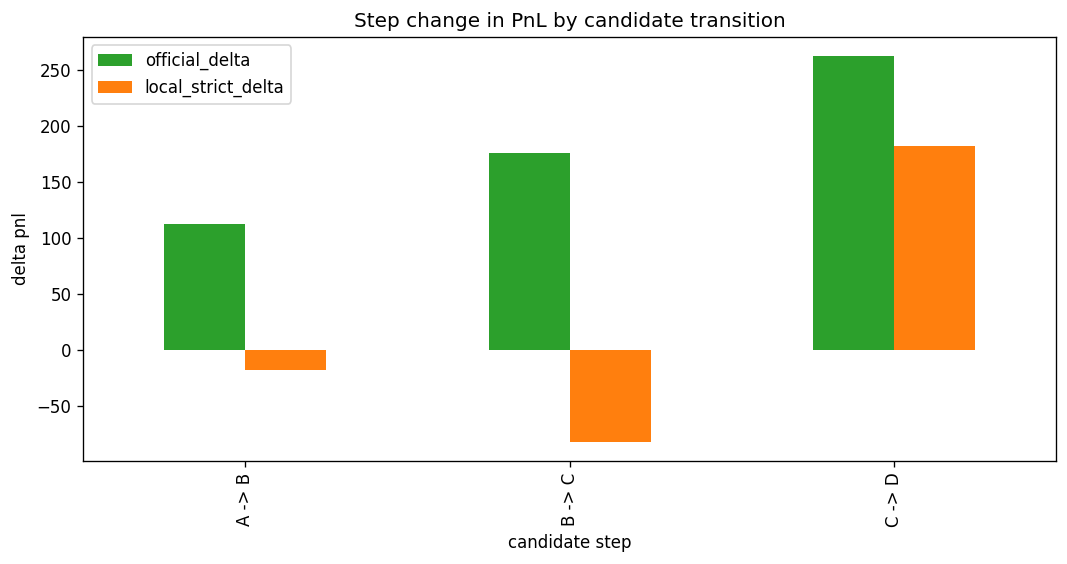

**Dominant proven step**: `C -> D` adds `261.84375` official PnL, the largest measured gain in the ladder.

That matters because `C -> D` changes only quote size and inventory capacity, not the core anchoring or dislocation logic.

In [7]:
relevant_fields = [
    'anchor_lookback',
    'base_half_spread',
    'inventory_skew',
    'imbalance_skew',
    'dislocation_threshold',
    'defensive_widening_multiplier',
    'max_quote_size',
    'inventory_soft_limit',
    'inventory_hard_limit',
    'enable_dislocation_takers',
    'dislocation_one_sided_only',
]

parameter_ladder = pd.DataFrame(
    [
        {'candidate': candidate, **{field: candidate_configs[candidate][field] for field in relevant_fields}}
        for candidate in CANDIDATE_ORDER
    ]
)
parameter_ladder = with_candidate_order(parameter_ladder, 'candidate')
display(parameter_ladder)

official_pnl_by_candidate = official_scoreboard.set_index('candidate')['official_pnl']
local_strict_pnl_by_candidate = strict_local_by_candidate.set_index('candidate')['net_pnl']

step_rows = []
for left, right in zip(CANDIDATE_ORDER, CANDIDATE_ORDER[1:]):
    changed_fields = []
    for field in relevant_fields:
        left_value = candidate_configs[left][field]
        right_value = candidate_configs[right][field]
        if left_value != right_value:
            changed_fields.append(f'{field} {left_value} -> {right_value}')
    step_rows.append(
        {
            'step': f'{left} -> {right}',
            'changed_fields': '; '.join(changed_fields),
            'official_delta': float(official_pnl_by_candidate[right] - official_pnl_by_candidate[left]),
            'local_strict_delta': float(local_strict_pnl_by_candidate[right] - local_strict_pnl_by_candidate[left]),
        }
    )

step_deltas = pd.DataFrame(step_rows)
display(step_deltas.round(6))

fig, ax = plt.subplots(figsize=(9, 4.8))
step_plot = step_deltas.set_index('step')[['official_delta', 'local_strict_delta']]
step_plot.plot(kind='bar', ax=ax, color=['tab:green', 'tab:orange'])
ax.set_title('Step change in PnL by candidate transition')
ax.set_xlabel('candidate step')
ax.set_ylabel('delta pnl')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

dominant_step = step_deltas.loc[step_deltas['official_delta'].idxmax()]
dominant_note = chr(10).join(
    [
        f"**Dominant proven step**: `{dominant_step['step']}` adds `{dominant_step['official_delta']:.5f}` official PnL, the largest measured gain in the ladder.",
        '',
        'That matters because `C -> D` changes only quote size and inventory capacity, not the core anchoring or dislocation logic.',
    ]
)
display(Markdown(dominant_note))


## Gap to 3500

Candidate `D` is the current official baseline. This section treats the measured `A -> D` step gains as evidence-based building blocks and shows how much of the remaining gap each lever could plausibly cover.


,best_candidate,best_official_pnl,remaining_gap_to_3500
0,D,1386.84375,2113.15625


,lever,evidence,pnl_chunk,share_of_remaining_gap
0,Capacity expansion,official C -> D gain,261.84375,0.123911
1,Quote-shape retune / less defensive widening,official B -> C gain,176.00000,0.083288
2,Inventory and anchor rebalance,official A -> B gain,112.43750,0.053208


,lever,evidence,pnl_chunk,share_of_remaining_gap
0,Controlled aggression and other new edge,residual after replaying all proven gains once,1562.875,0.739593


,scenario,projected_official_pnl,remaining_gap_to_3500
0,Current D,1386.84375,2113.15625
1,D + capacity replay,1648.68750,1851.31250
2,D + capacity + quote-shape retune,1824.68750,1675.31250
3,D + replay all proven A -> D gains once,1937.12500,1562.87500
4,Target,3500.00000,0.00000


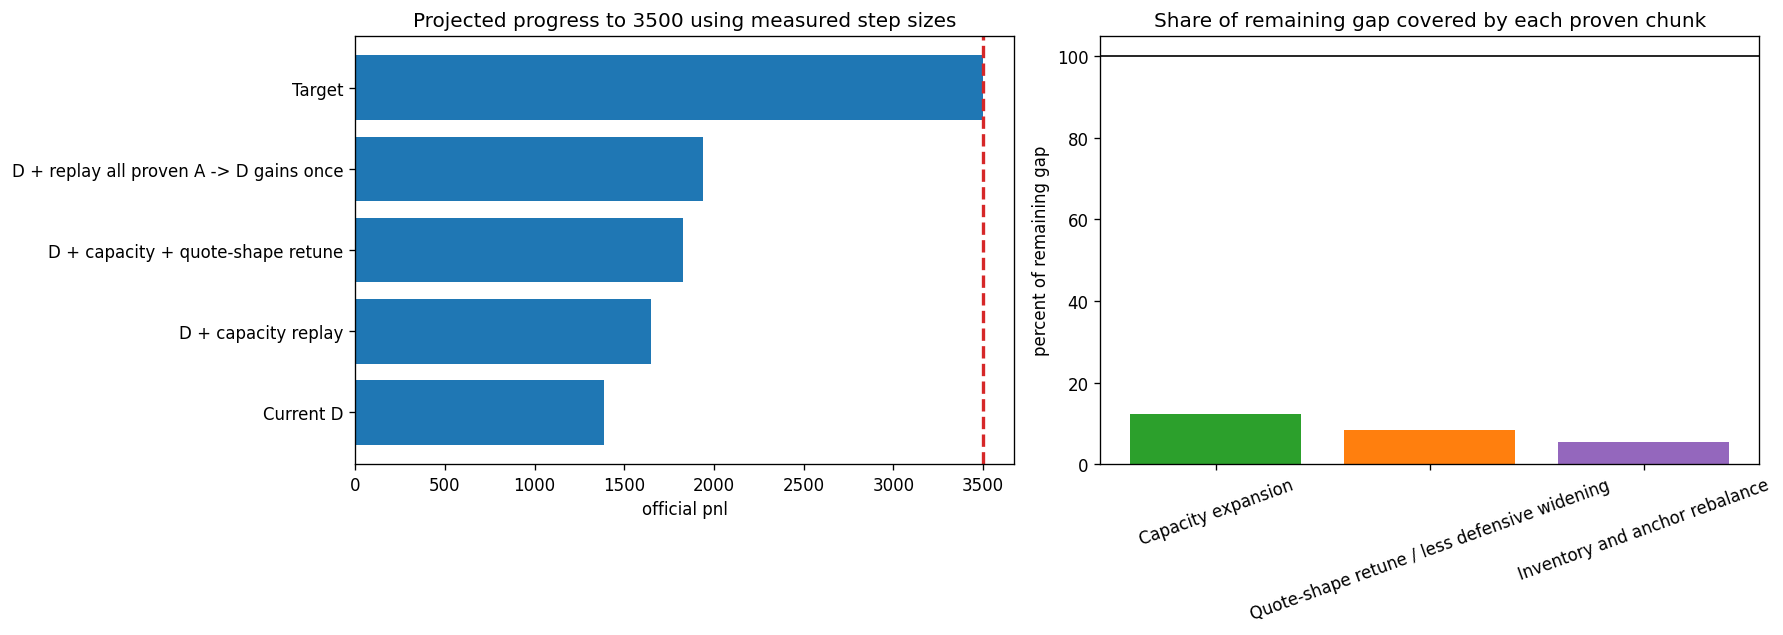

**Gap framing**

- Candidate `D` is at `1386.84375`, leaving `2113.15625` still missing to reach `3500.0`.
- Replaying a second `C -> D` sized capacity gain would only move the official result to `1648.68750`.
- Replaying the proven capacity gain plus the proven `B -> C` quote-shape gain still leaves `1675.31250` missing.
- Even replaying all proven `A -> D` gains once more only reaches `1937.12500`, so a new edge source is still required.

In [8]:
best_candidate = str(official_ranking.loc[0, 'candidate'])
best_official_pnl = float(official_ranking.loc[0, 'official_pnl'])
remaining_gap = float(TARGET_OFFICIAL_PNL - best_official_pnl)

step_gain_map = step_deltas.set_index('step')['official_delta']
capacity_gain = float(step_gain_map['C -> D'])
quote_shape_gain = float(step_gain_map['B -> C'])
anchor_rebalance_gain = float(step_gain_map['A -> B'])
total_proven_gain = float(official_pnl_by_candidate['D'] - official_pnl_by_candidate['A'])

proven_gap_sources = pd.DataFrame(
    [
        {
            'lever': 'Capacity expansion',
            'evidence': 'official C -> D gain',
            'pnl_chunk': capacity_gain,
        },
        {
            'lever': 'Quote-shape retune / less defensive widening',
            'evidence': 'official B -> C gain',
            'pnl_chunk': quote_shape_gain,
        },
        {
            'lever': 'Inventory and anchor rebalance',
            'evidence': 'official A -> B gain',
            'pnl_chunk': anchor_rebalance_gain,
        },
    ]
)
proven_gap_sources['share_of_remaining_gap'] = proven_gap_sources['pnl_chunk'] / remaining_gap

residual_after_all_proven_replays = float(remaining_gap - proven_gap_sources['pnl_chunk'].sum())
residual_after_capacity_and_quote_shape = float(remaining_gap - capacity_gain - quote_shape_gain)

aggression_budget = pd.DataFrame(
    [
        {
            'lever': 'Controlled aggression and other new edge',
            'evidence': 'residual after replaying all proven gains once',
            'pnl_chunk': residual_after_all_proven_replays,
            'share_of_remaining_gap': residual_after_all_proven_replays / remaining_gap,
        }
    ]
)

scenario_budget = pd.DataFrame(
    [
        {'scenario': 'Current D', 'projected_official_pnl': best_official_pnl},
        {'scenario': 'D + capacity replay', 'projected_official_pnl': best_official_pnl + capacity_gain},
        {
            'scenario': 'D + capacity + quote-shape retune',
            'projected_official_pnl': best_official_pnl + capacity_gain + quote_shape_gain,
        },
        {
            'scenario': 'D + replay all proven A -> D gains once',
            'projected_official_pnl': best_official_pnl + total_proven_gain,
        },
        {'scenario': 'Target', 'projected_official_pnl': TARGET_OFFICIAL_PNL},
    ]
)
scenario_budget['remaining_gap_to_3500'] = TARGET_OFFICIAL_PNL - scenario_budget['projected_official_pnl']

display(pd.DataFrame([{'best_candidate': best_candidate, 'best_official_pnl': best_official_pnl, 'remaining_gap_to_3500': remaining_gap}]).round(6))
display(proven_gap_sources.round(6))
display(aggression_budget.round(6))
display(scenario_budget.round(6))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

axes[0].barh(scenario_budget['scenario'], scenario_budget['projected_official_pnl'], color='tab:blue')
axes[0].axvline(TARGET_OFFICIAL_PNL, color='tab:red', linestyle='--', linewidth=2)
axes[0].set_title('Projected progress to 3500 using measured step sizes')
axes[0].set_xlabel('official pnl')

axes[1].bar(proven_gap_sources['lever'], proven_gap_sources['share_of_remaining_gap'] * 100.0, color=['tab:green', 'tab:orange', 'tab:purple'])
axes[1].axhline(100.0, color='black', linewidth=1)
axes[1].set_title('Share of remaining gap covered by each proven chunk')
axes[1].set_ylabel('percent of remaining gap')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

gap_note = chr(10).join(
    [
        '**Gap framing**',
        '',
        f'- Candidate `D` is at `{best_official_pnl:.5f}`, leaving `{remaining_gap:.5f}` still missing to reach `3500.0`.',
        f'- Replaying a second `C -> D` sized capacity gain would only move the official result to `{best_official_pnl + capacity_gain:.5f}`.',
        f'- Replaying the proven capacity gain plus the proven `B -> C` quote-shape gain still leaves `{residual_after_capacity_and_quote_shape:.5f}` missing.',
        f'- Even replaying all proven `A -> D` gains once more only reaches `{best_official_pnl + total_proven_gain:.5f}`, so a new edge source is still required.',
    ]
)
display(Markdown(gap_note))


## Validation checks

These assertions make sure the notebook is reading the saved artifacts correctly and is using the requested `3500.0` target.


In [9]:
expected_official_pnl = {
    'A': 836.5625,
    'B': 949.0,
    'C': 1125.0,
    'D': 1386.84375,
}
for candidate, expected in expected_official_pnl.items():
    actual = float(official_pnl_by_candidate[candidate])
    assert abs(actual - expected) < 1e-9, f'Official PnL mismatch for {candidate}: {actual} != {expected}'

assert best_candidate == 'D', f'Expected D as official best candidate, got {best_candidate}'
assert str(strict_local_ranking.loc[0, 'candidate']) == 'D', 'Local strict ranking should still rank D first'

c_to_d_changed_fields = [
    field for field in relevant_fields if candidate_configs['C'][field] != candidate_configs['D'][field]
]
assert c_to_d_changed_fields == ['max_quote_size', 'inventory_soft_limit', 'inventory_hard_limit'], c_to_d_changed_fields

assert abs(TARGET_OFFICIAL_PNL - 3500.0) < 1e-12
assert abs(remaining_gap - 2113.15625) < 1e-9

validation_checks = pd.DataFrame(
    [
        {'check': 'official PnL table matches saved IMC exports', 'passed': True},
        {'check': 'local strict ranking still places D first', 'passed': True},
        {'check': 'C -> D is a pure size and inventory-capacity change', 'passed': True},
        {'check': 'target PnL is fixed at 3500.0', 'passed': True},
        {'check': 'gap from D to target equals 2113.15625', 'passed': True},
    ]
)
display(validation_checks)


,check,passed
0,official PnL table matches saved IMC exports,True
1,local strict ranking still places D first,True
2,C -> D is a pure size and inventory-capacity c...,True
3,target PnL is fixed at 3500.0,True
4,gap from D to target equals 2113.15625,True


## Conclusions and roadmap


In [10]:
conclusions = chr(10).join(
    [
        '**Conclusions**',
        '',
        f'- `D` is the current official best candidate at `{best_official_pnl:.5f}` and should remain the baseline for future IMC reruns.',
        f'- Size and inventory capacity are the strongest proven lever so far: the `C -> D` step adds `{capacity_gain:.5f}` official PnL, the largest measured gain in the ladder.',
        f'- Capacity alone is necessary but not sufficient. A second `C -> D` sized jump still leaves `{remaining_gap - capacity_gain:.5f}` missing versus the `3500.0` target.',
        '- The local proxy is still useful because it keeps `D` on top and shows higher fill quantity capacity, but it understates the official payoff from the later ladder steps and therefore cannot be used as the final ranking source.',
        '',
        '**Next experiment ladder**',
        '',
        '1. `E`: replay the `C -> D` capacity step once more with `max_quote_size=15`, `inventory_soft_limit=36`, and `inventory_hard_limit=60`.',
        '2. `F`: keep the `E` capacity envelope and retune quote shape by reducing `defensive_widening_multiplier` to `1.25`.',
        '3. `G`: keep the `F` quote shape and add conservative micro-takers with `aggressive_size=2.0` and `strong_dislocation_buffer=4.0`.',
        '',
        'This roadmap now maps directly to the local `D/E/F/G` next-round family while keeping the official `A-D` comparison unchanged.',
    ]
)
display(Markdown(conclusions))


**Conclusions**

- `D` is the current official best candidate at `1386.84375` and should remain the baseline for future IMC reruns.
- Size and inventory capacity are the strongest proven lever so far: the `C -> D` step adds `261.84375` official PnL, the largest measured gain in the ladder.
- Capacity alone is necessary but not sufficient. A second `C -> D` sized jump still leaves `1851.31250` missing versus the `3500.0` target.
- The local proxy is still useful because it keeps `D` on top and shows higher fill quantity capacity, but it understates the official payoff from the later ladder steps and therefore cannot be used as the final ranking source.

**Next experiment ladder**

1. `E`: replay the `C -> D` capacity step once more with `max_quote_size=15`, `inventory_soft_limit=36`, and `inventory_hard_limit=60`.
2. `F`: keep the `E` capacity envelope and retune quote shape by reducing `defensive_widening_multiplier` to `1.25`.
3. `G`: keep the `F` quote shape and add conservative micro-takers with `aggressive_size=2.0` and `strong_dislocation_buffer=4.0`.

This roadmap now maps directly to the local `D/E/F/G` next-round family while keeping the official `A-D` comparison unchanged.